# Mechanical property prediction

Predicts the tensile strength $\sigma_u$ and toughness $U_T$ of a contracted binary Bar–Y superlattice from the branch lengths $\mathbf{x} = [L_{0,\mathrm{Bar}},\, L_{0,\mathrm{Y}}]$, together with a calibrated predictive uncertainty.

* **Data**: the 118 contracted designs; each property is the average over the simulation replicates of a design (`data/Supplementary Data 3.xlsx`).
* **Model**: an ensemble of 20 neural networks (PyTorch) trained on bootstrap resamples of the training data. The ensemble mean $\hat\mu$ is the prediction, the standard deviation across members $\hat\sigma_{\mathrm{ori}}$ quantifies the model uncertainty, and a linear rescaling $\hat\sigma_{\mathrm{cal}} = a\,\hat\sigma_{\mathrm{ori}} + b$ calibrates it against out-of-sample residuals (Palmer et al., *npj Comput. Mater.* 2022).
* **Sections**: 1 dataset and fixed split · 2 network architecture selection · 3 benchmark against conventional surrogates over 20 random splits · 4 uncertainty calibration · 5 prediction intervals on the held-out designs · 6 learning curve · 7 deployed ensemble.

The deployed ensemble is saved to `models/nn_ensemble/` and used by `pareto_optimization.ipynb`.

In [1]:
import json, os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy import stats
import torch

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold, RepeatedKFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

import mega_utils as mu

mu.apply_plot_style()

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

N_JOBS = 16
RETRAIN = False        # False: load the saved results and models and only draw the tables and figures; True: retrain everything
OUTPUTS = list(mu.OUTPUTS)
UNITS = {o: mu.OUTPUT_UNITS[o] for o in OUTPUTS}

pts = mu.load_points()
X_all, Y_all = mu.xy(pts)

# fixed split: 70 training / 24 validation / 24 testing designs
IDX_TRAIN, IDX_VAL, IDX_TEST = mu.property_fixed_split(len(pts))
IDX_TRAINVAL = np.array(sorted(set(IDX_TRAIN) | set(IDX_VAL)))     # 94 designs
print(f"{len(pts)} designs: train {len(IDX_TRAIN)} / validation {len(IDX_VAL)} / test {len(IDX_TEST)}")
pts.head()

118 designs: train 70 / validation 24 / test 24


,L0Bar,L0Y,Strength,Toughness,n,Class
0,1.0,1.2,42.815705,22.262872,4,2
1,1.0,1.3,59.382789,10.058175,3,2
2,1.0,1.4,20.895857,16.567611,5,2
3,1.0,1.8,18.492774,14.049413,3,3
4,1.0,1.9,71.317371,22.800199,5,3


## 1. Dataset

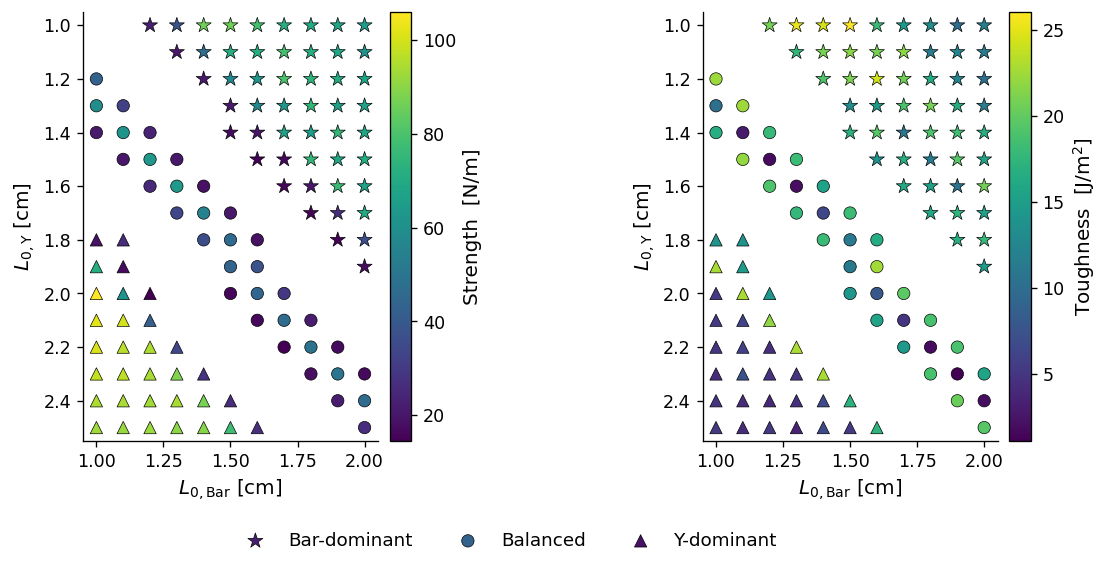

In [2]:
TYPE_MARKER = {"Bar-dominant": "*", "Balanced": "o", "Y-dominant": "^"}
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6))
for ax, o in zip(axes, OUTPUTS):
    for k, name in mu.CLASS_NAMES.items():
        d = pts[pts.Class == k]
        if len(d) == 0:
            continue
        sc = ax.scatter(d.L0Bar, d.L0Y, c=d[o], marker=TYPE_MARKER[name], s=90 if k == 1 else 55,
                        cmap="viridis", vmin=pts[o].min(), vmax=pts[o].max(), edgecolors="k", linewidths=0.4, label=name)
    plt.colorbar(sc, ax=ax, pad=0.02).set_label(f"{o}  [{UNITS[o]}]")
    ax.set_xlabel("$L_{0,\\mathrm{Bar}}$ [cm]"); ax.set_ylabel("$L_{0,\\mathrm{Y}}$ [cm]")
    ax.set_xlim(0.95, 2.05); ax.set_ylim(2.55, 0.95); ax.set_aspect("equal")
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", bbox_to_anchor=(0.5, -0.04), ncol=3, frameon=False)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## 2. Network architecture selection

The architecture is selected on the fixed split. Inputs and targets are standardised with the mean and standard deviation of the 70 training designs, each candidate is trained on the training designs (full-batch Adam, learning rate $5\times10^{-4}$, MSE loss, early stopping on the training loss) and scored by the mean of the normalised MSE of the two standardised targets on the 24 validation designs (Supplementary Table 4).

In [3]:
HIDDEN_GRID = [[16], [32], [16, 16], [32, 16], [32, 32], [16, 16, 16], [16, 32, 16]]
ACT_GRID = ["ReLU", "Tanh", "Sigmoid"]
LR = 5e-4

xs0, ys0 = mu.Standardiser().fit(X_all[IDX_TRAIN]), mu.Standardiser().fit(Y_all[IDX_TRAIN])
Xtr0, Ytr0 = xs0.transform(X_all[IDX_TRAIN]), ys0.transform(Y_all[IDX_TRAIN])
Xva0, Yva0 = xs0.transform(X_all[IDX_VAL]), ys0.transform(Y_all[IDX_VAL])


def fit_single_nn(Xs, Ys, hidden_sizes, activation, seed=42):
    torch.set_num_threads(1)
    mu.set_seed(seed)                                     # seed the weight initialisation
    net = mu.build_mlp(hidden_sizes=hidden_sizes, activation=activation, dropout=0.0)
    return mu.train_mlp(net, Xs, Ys, lr=LR, seed=seed)


def grid_job(hidden_sizes, activation):
    net = fit_single_nn(Xtr0, Ytr0, hidden_sizes, activation)
    mse = ((mu.predict_mlp(net, Xva0) - Yva0) ** 2).mean(axis=0)
    return {"hidden_sizes": str(hidden_sizes), "activation": activation,
            "val_nMSE_Strength": float(mse[0]), "val_nMSE_Toughness": float(mse[1]), "val_nMSE_average": float(mse.mean())}


if RETRAIN:
    arch = pd.DataFrame(Parallel(n_jobs=N_JOBS, verbose=1)(delayed(grid_job)(h, a) for h in HIDDEN_GRID for a in ACT_GRID))
    mu.save_results(arch, "nn_architecture_grid.csv")
else:
    arch = mu.load_results("nn_architecture_grid.csv")

best = arch.loc[arch.val_nMSE_average.idxmin()]
MLP_KW = dict(hidden_sizes=json.loads(best.hidden_sizes), activation=best.activation, dropout=0.0)
print(f"selected architecture: hidden sizes {MLP_KW['hidden_sizes']}, {MLP_KW['activation']} activation "
      f"(validation nMSE {best.val_nMSE_average:.3f})")
arch.round(3)

selected architecture: hidden sizes [16, 32, 16], Sigmoid activation (validation nMSE 0.094)


,hidden_sizes,activation,val_nMSE_Strength,val_nMSE_Toughness,val_nMSE_average
0,[16],ReLU,0.325,0.688,0.507
1,[16],Tanh,0.128,0.493,0.311
2,[16],Sigmoid,0.362,0.717,0.540
3,[32],ReLU,0.145,0.650,0.398
4,[32],Tanh,0.188,1.904,1.046
5,[32],Sigmoid,0.211,0.774,0.492
6,"[16, 16]",ReLU,0.186,0.448,0.317
7,"[16, 16]",Tanh,0.223,0.550,0.387
8,"[16, 16]",Sigmoid,0.085,0.252,0.168
9,"[32, 16]",ReLU,0.162,0.240,0.201


## 3. Benchmark over 20 random 80/20 splits

With the architecture fixed, the single network and the bootstrap ensemble are compared with four conventional surrogates over 20 random 80/20 training/testing splits. Inputs and targets are standardised on the training part of each split. The conventional surrogates are tuned by a five-fold grid search inside the training data of every split:

| model | tuned hyperparameters |
|---|---|
| GPR (one GP per property) | kernel $\in$ {isotropic RBF, ARD RBF, ARD Matérn 3/2, ARD Matérn 5/2}, plus a white-noise term; continuous hyperparameters by marginal likelihood |
| *k*-NN | $k \in \{1, 3, 5, 7, 10\}$, uniform or distance weights |
| polynomial RSM | degree $\in \{1, 2, 3, 4\}$, ridge penalty $\in \{10^{-12}, 10^{-3}, 10^{-2}, 10^{-1}\}$ |
| random forest | maximum depth $\in \{\text{none}, 4, 8\}$, features per split $\in \{1, 2\}$, 400 trees |

The NN ensemble consists of 20 networks, each trained on a bootstrap resample of the training part. Testing $R^2$ and RMSE are computed per split in physical units and summarised as mean ± standard deviation over the 20 splits (Supplementary Table 5).

In [4]:
def gp_kernel(name):
    if name == "RBF-iso":
        base = RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
    elif name == "RBF-ARD":
        base = RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e2))
    elif name == "Matern1.5-ARD":
        base = Matern(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e2), nu=1.5)
    else:
        base = Matern(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e2), nu=2.5)
    return ConstantKernel(1.0, (1e-3, 1e3)) * base + WhiteKernel(1e-4, (1e-10, 1e1))


class GPSurrogate(BaseEstimator, RegressorMixin):
    # one GP per property; the kernel family is a tunable hyperparameter
    def __init__(self, kernel="RBF-iso"):
        self.kernel = kernel

    def fit(self, Xs, Ys):
        self.models_ = [GaussianProcessRegressor(kernel=gp_kernel(self.kernel), alpha=0.0, n_restarts_optimizer=5,
                                                 random_state=42).fit(Xs, Ys[:, j]) for j in range(Ys.shape[1])]
        return self

    def predict(self, Xs):
        return np.column_stack([g.predict(Xs) for g in self.models_])


INNER_CV = KFold(n_splits=5, shuffle=True, random_state=0)
GRIDS = {
    "GPR": (GPSurrogate(), {"kernel": ["RBF-iso", "RBF-ARD", "Matern1.5-ARD", "Matern2.5-ARD"]}),
    "k-NN": (KNeighborsRegressor(), {"n_neighbors": [1, 3, 5, 7, 10], "weights": ["uniform", "distance"]}),
    "PRSM": (make_pipeline(PolynomialFeatures(), Ridge()),
             {"polynomialfeatures__degree": [1, 2, 3, 4], "ridge__alpha": [1e-12, 1e-3, 1e-2, 1e-1]}),
    "RF": (RandomForestRegressor(n_estimators=400, random_state=42), {"max_depth": [None, 4, 8], "max_features": [1, 2]}),
}
BASELINES = list(GRIDS)
B = 20                                   # ensemble members
splits = mu.repeated_random(len(pts), n_repeats=20, test_size=0.2)


def split_scalers(sp):
    xs, ys = mu.Standardiser().fit(X_all[sp.train]), mu.Standardiser().fit(Y_all[sp.train])
    return xs, ys, xs.transform(X_all[sp.train]), ys.transform(Y_all[sp.train]), xs.transform(X_all[sp.test])


def record(model, sp, pred):
    rows = []
    for r_, i in enumerate(sp.test):
        rec = {"model": model, "split": sp.fold, "point": int(i), "L0Bar": float(X_all[i, 0]), "L0Y": float(X_all[i, 1])}
        for j, o in enumerate(OUTPUTS):
            rec[f"true_{o}"], rec[f"pred_{o}"] = float(Y_all[i, j]), float(pred[r_, j])
        rows.append(rec)
    return rows


def single_models_job(sp):
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    xs, ys, Xtr, Ytr, Xte = split_scalers(sp)
    rows = record("NN", sp, ys.inverse(mu.predict_mlp(fit_single_nn(Xtr, Ytr, **{k: v for k, v in MLP_KW.items() if k != "dropout"}), Xte)))
    for name, (est, grid) in GRIDS.items():
        m = GridSearchCV(est, grid, cv=INNER_CV, scoring="neg_mean_squared_error", n_jobs=1).fit(Xtr, Ytr)
        rows += record(name, sp, ys.inverse(np.asarray(m.predict(Xte), float)))
    return rows


def member_job(rep, sp, m):
    xs, ys, Xtr, Ytr, Xte = split_scalers(sp)
    net, _ = mu.train_bootstrap_member(Xtr, Ytr, seed=200000 + 1000 * rep + m, mlp_kw=MLP_KW, lr=LR)
    return {"split": sp.fold, "member": m, "pred": ys.inverse(mu.predict_mlp(net, Xte))}


if not RETRAIN:
    preds = mu.load_results("property_benchmark_predictions.csv")
else:
    out = Parallel(n_jobs=N_JOBS, verbose=1, max_nbytes=None)(delayed(single_models_job)(sp) for sp in splits)
    rows = [r for rr in out for r in rr]
    members = Parallel(n_jobs=N_JOBS, verbose=1, max_nbytes=None)(
        delayed(member_job)(rep, sp, m) for rep, sp in enumerate(splits) for m in range(B))
    for sp in splits:
        P = np.stack([d["pred"] for d in members if d["split"] == sp.fold])
        rows += record("NN ensemble", sp, P.mean(axis=0))
    preds = pd.DataFrame(rows)
    mu.save_results(preds, "property_benchmark_predictions.csv")

MODELS = ["NN"] + BASELINES + ["NN ensemble"]
per_split = []
for (name, s), g in preds.groupby(["model", "split"]):
    rec = {"model": name, "split": s}
    for o in OUTPUTS:
        rec[f"R2_{o}"] = mu.r2(g[f"true_{o}"], g[f"pred_{o}"]); rec[f"RMSE_{o}"] = mu.rmse(g[f"true_{o}"], g[f"pred_{o}"])
    per_split.append(rec)
per_split = pd.DataFrame(per_split)
if RETRAIN:
    mu.save_results(per_split, "property_benchmark_per_split.csv")
summary = per_split.drop(columns="split").groupby("model").agg(["mean", "std"]).loc[MODELS]
summary.columns = [f"{a}_{b}" for a, b in summary.columns]
if RETRAIN:
    mu.save_results(summary.reset_index(), "property_benchmark_summary.csv")

table = pd.DataFrame({name: [f"{summary.loc[name, f'R2_{o}_mean']:.2f} ± {summary.loc[name, f'R2_{o}_std']:.2f}" for o in OUTPUTS]
                            + [f"{summary.loc[name, f'RMSE_{o}_mean']:.1f} ± {summary.loc[name, f'RMSE_{o}_std']:.1f}" for o in OUTPUTS]
                      for name in MODELS},
                     index=[f"R2, {o.lower()}" for o in OUTPUTS] + [f"RMSE, {o.lower()} [{UNITS[o]}]" for o in OUTPUTS])
table

,NN,GPR,k-NN,PRSM,RF,NN ensemble
"R2, strength",0.95 ± 0.04,0.68 ± 0.11,0.54 ± 0.18,0.49 ± 0.11,0.41 ± 0.18,0.93 ± 0.06
"R2, toughness",0.77 ± 0.13,0.09 ± 0.23,0.22 ± 0.26,0.25 ± 0.26,0.06 ± 0.31,0.70 ± 0.19
"RMSE, strength [N/m]",5.6 ± 2.3,15.6 ± 2.4,18.7 ± 2.9,20.1 ± 1.7,21.5 ± 2.8,6.8 ± 2.9
"RMSE, toughness [J/m$^2$]",2.8 ± 0.7,5.8 ± 0.8,5.3 ± 0.9,5.2 ± 1.1,5.8 ± 1.0,3.2 ± 0.9


The network is considerably more accurate than the conventional surrogates for both properties. The ensemble is slightly less accurate than the single network because each bootstrap member sees only about 63 % of the distinct training designs, but it provides a predictive uncertainty and is therefore adopted for property prediction.

## 4. Uncertainty calibration

The ensemble spread $\hat\sigma_{\mathrm{ori}}$ is calibrated following Palmer et al. (2022):

1. The 24 testing designs of the fixed split are held out; the remaining 94 designs form the training set.
2. A five-fold cross-validation repeated four times inside the 94 training designs gives 20 inner training/validation splits. An ensemble of 20 networks is trained on each inner training part and evaluated on its validation part, which yields 376 out-of-fold pairs of residual and $\hat\sigma_{\mathrm{ori}}$ per property.
3. The calibration factors $(a, b)$ minimise the Gaussian negative log-likelihood $\sum_i \big[\ln(a\hat\sigma_{\mathrm{ori},i} + b) + r_i^2 / (2 (a\hat\sigma_{\mathrm{ori},i} + b)^2)\big]$ of these pairs (Nelder–Mead).
4. The deployed ensemble is trained on all 94 training designs and its spread is rescaled with $(a, b)$.

In [5]:
rkf = RepeatedKFold(n_splits=5, n_repeats=4, random_state=0)
L2 = [{"split": k, "train": IDX_TRAINVAL[tr_], "val": IDX_TRAINVAL[va_]} for k, (tr_, va_) in enumerate(rkf.split(IDX_TRAINVAL))]


def cal_member_job(kind, split_id, train_idx, eval_idx, seed):
    xs, ys = mu.Standardiser().fit(X_all[train_idx]), mu.Standardiser().fit(Y_all[train_idx])
    net, _ = mu.train_bootstrap_member(xs.transform(X_all[train_idx]), ys.transform(Y_all[train_idx]), seed, MLP_KW, LR)
    pred = ys.inverse(mu.predict_mlp(net, xs.transform(X_all[eval_idx])))
    return {"kind": kind, "split": split_id, "seed": seed, "eval_idx": eval_idx, "pred": pred,
            "state_dict": net.state_dict() if kind == "final" else None}


ENS_DIR = os.path.join(mu.MODELS_DIR, "nn_ensemble")
xs_f, ys_f = mu.Standardiser().fit(X_all[IDX_TRAINVAL]), mu.Standardiser().fit(Y_all[IDX_TRAINVAL])

if not RETRAIN:
    oof = mu.load_results("calibration_oof_pairs.csv")
    ensemble = mu.NNEnsemble.load(ENS_DIR)
    AB = ensemble.ab
else:
    jobs = [("inner", s["split"], s["train"], s["val"], 1000 * s["split"] + m) for s in L2 for m in range(B)]
    jobs += [("final", 0, IDX_TRAINVAL, np.arange(len(pts)), 100000 + m) for m in range(B)]
    print(f"training {len(jobs)} networks ...")
    res = Parallel(n_jobs=N_JOBS, verbose=1, max_nbytes=None)(delayed(cal_member_job)(*j) for j in jobs)

    # out-of-fold pairs from the 20 inner ensembles
    oof_rows = []
    for s in L2:
        P = np.stack([d["pred"] for d in res if d["kind"] == "inner" and d["split"] == s["split"]])
        mu_, sd_ = P.mean(axis=0), P.std(axis=0, ddof=1)
        for r_, i in enumerate(s["val"]):
            rec = {"split": s["split"], "repeat": s["split"] // 5, "point": int(i)}
            for j, o in enumerate(OUTPUTS):
                rec[f"true_{o}"], rec[f"mu_{o}"], rec[f"sigma_uc_{o}"] = float(Y_all[i, j]), float(mu_[r_, j]), float(sd_[r_, j])
                rec[f"resid_{o}"] = float(Y_all[i, j] - mu_[r_, j])
            oof_rows.append(rec)
    oof = pd.DataFrame(oof_rows)

    AB = {}
    for o in OUTPUTS:
        AB[o] = mu.fit_calibration(oof[f"sigma_uc_{o}"], oof[f"resid_{o}"])
        oof[f"sigma_cal_{o}"] = AB[o][0] * oof[f"sigma_uc_{o}"] + AB[o][1]
    mu.save_results(oof, "calibration_oof_pairs.csv")

    # the deployed ensemble: 20 members trained on the 94 training designs, with the calibration factors
    nets = []
    for d in sorted([d for d in res if d["kind"] == "final"], key=lambda d: d["seed"]):
        net = mu.build_mlp(**MLP_KW); net.load_state_dict(d["state_dict"]); net.eval(); nets.append(net)
    ensemble = mu.NNEnsemble(nets, xs_f, ys_f, AB, MLP_KW)
    ensemble.save(ENS_DIR)
    print("saved models/nn_ensemble/ (20 members, standardiser and calibration factors)")

factors = pd.DataFrame([{"output": o, "a": AB[o][0], "b": AB[o][1], "n_pairs": len(oof)} for o in OUTPUTS])
if RETRAIN:
    mu.save_results(factors, "calibration_factors.csv")
print(f"{len(oof)} out-of-fold pairs ({oof.point.nunique()} designs x {oof.repeat.nunique()} repeats)")
factors.round(3)

376 out-of-fold pairs (94 designs x 4 repeats)


,output,a,b,n_pairs
0,Strength,0.625,1.344,376
1,Toughness,0.561,1.091,376


In [6]:
# the deployed ensemble at the 118 designs

mu_d, sd_d, cal_d = ensemble.predict(X_all)
designs = pd.DataFrame({"point": np.arange(len(pts)), "L0Bar": X_all[:, 0], "L0Y": X_all[:, 1], "Class": pts.Class})
for j, o in enumerate(OUTPUTS):
    designs[f"true_{o}"], designs[f"mu_{o}"] = Y_all[:, j], mu_d[:, j]
    designs[f"sigma_uc_{o}"], designs[f"sigma_cal_{o}"] = sd_d[:, j], cal_d[:, j]
designs["test"] = np.isin(designs.point, IDX_TEST)
if RETRAIN:
    mu.save_results(designs, "property_ensemble_designs.csv")
designs.head().round(2)

,point,L0Bar,L0Y,Class,true_Strength,mu_Strength,sigma_uc_Strength,sigma_cal_Strength,true_Toughness,mu_Toughness,sigma_uc_Toughness,sigma_cal_Toughness,test
0,0,1.0,1.2,2,42.82,34.43,17.08,12.01,22.26,12.50,7.04,5.04,True
1,1,1.0,1.3,2,59.38,50.94,14.77,10.57,10.06,8.34,5.68,4.28,False
2,2,1.0,1.4,2,20.90,20.60,4.33,4.05,16.57,19.46,2.68,2.60,False
3,3,1.0,1.8,3,18.49,22.43,8.70,6.78,14.05,15.91,4.42,3.57,False
4,4,1.0,1.9,3,71.32,48.77,21.76,14.94,22.80,21.03,4.13,3.41,True


### Calibration diagnostics

For each property, the uncalibrated and the calibrated uncertainty estimates are compared on the 376 out-of-fold pairs (Supplementary Fig. 16 and Table 6). Left: distribution of the $r$-statistic $r = \mathrm{residual}/\hat\sigma$ against the standard normal density. Middle: Q–Q plot of $r$. Right: distribution of $\hat\sigma$ (top) and the root-mean-square residual of the pairs binned by $\hat\sigma$ (bottom), with a count-weighted linear fit; hollow markers denote bins with fewer than 30 pairs and the dashed line is the identity, on which a perfectly calibrated estimate would lie.

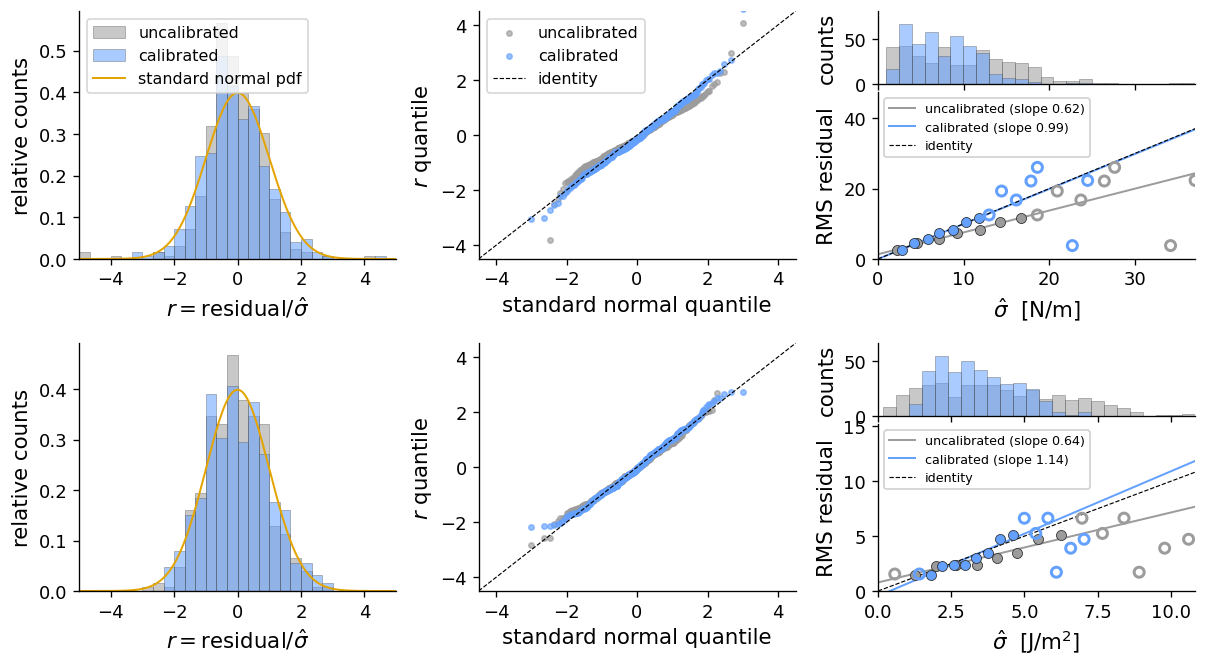

,Property,Uncertainty estimate,r-stat mean,r-stat s.d.,RvE slope,RvE intercept,RvE R2,a,b
0,Strength,uncalibrated,-0.08,0.91,0.62,1.34,0.90,NaN,NaN
1,Strength,calibrated,-0.09,1.00,0.99,0.00,0.90,0.62,1.34
2,Toughness,uncalibrated,0.11,1.69,0.64,0.78,0.84,NaN,NaN
3,Toughness,calibrated,0.01,1.00,1.14,-0.46,0.84,0.56,1.09


In [35]:
VARIANT = {"sigma_uc": ("uncalibrated", mu.GREY), "sigma_cal": ("calibrated", mu.BLUE)}
PALMER = {}
with mpl.rc_context({"font.size": 12, "axes.labelsize": 12.8, "xtick.labelsize": 10.8, "ytick.labelsize": 10.8, "legend.fontsize": 9.6}):
    fig = plt.figure(figsize=(12, 6.4))
    outer = fig.add_gridspec(2, 3, hspace=0.34, wspace=0.26)
    for i, o in enumerate(OUTPUTS):
        ax = fig.add_subplot(outer[i, 0])
        for col in VARIANT:
            lab, c = VARIANT[col]
            ax.hist((oof[f"resid_{o}"] / oof[f"{col}_{o}"]).to_numpy(), bins=30, range=(-5, 5), density=True, alpha=0.55,
                    color=c, edgecolor="0.3", linewidth=0.4, label=lab)
        xx = np.linspace(-5, 5, 200)
        ax.plot(xx, stats.norm.pdf(xx), c="#E4A400", lw=1.2, label="standard normal pdf")
        ax.set_xlim(-5, 5); ax.set_xlabel(r"$r = \mathrm{residual} / \hat\sigma$"); ax.set_ylabel("relative counts")
        if i == 0: ax.legend(frameon=True, loc="upper left")
        ax = fig.add_subplot(outer[i, 1])
        for col in VARIANT:
            lab, c = VARIANT[col]
            z = np.sort((oof[f"resid_{o}"] / oof[f"{col}_{o}"]).to_numpy()); n = len(z)
            ax.scatter(stats.norm.ppf((np.arange(1, n + 1) - 0.5) / n), z, s=10, c=c, alpha=0.65, label=lab)
        ax.plot([-4.5, 4.5], [-4.5, 4.5], "k--", lw=0.7, label="identity")
        ax.set_xlim(-4.5, 4.5); ax.set_ylim(-4.5, 4.5); ax.set_xlabel("standard normal quantile"); ax.set_ylabel(r"$r$ quantile")
        if i == 0: ax.legend(frameon=True, loc="upper left")
        inner = outer[i, 2].subgridspec(2, 1, height_ratios=[1, 2.3], hspace=0.07)
        ax_top = fig.add_subplot(inner[0]); ax_bot = fig.add_subplot(inner[1], sharex=ax_top)
        smin = min(oof[f"sigma_uc_{o}"].min(), oof[f"sigma_cal_{o}"].min())
        smax = max(oof[f"sigma_uc_{o}"].max(), oof[f"sigma_cal_{o}"].max())
        bins = np.linspace(smin, smax, 25)
        for col in VARIANT:
            lab, c = VARIANT[col]
            ax_top.hist(oof[f"{col}_{o}"], bins=bins, alpha=0.55, color=c, edgecolor="0.3", linewidth=0.4, label=lab)
        ax_top.set_ylabel("counts"); ax_top.tick_params(labelbottom=False); ax_top.margins(y=0.22)
        for col in VARIANT:
            lab, c = VARIANT[col]
            st, tab = mu.rve_stats(oof[f"{col}_{o}"], oof[f"resid_{o}"])
            PALMER[(o, col)] = st
            full, hollow = tab[tab.n >= 30], tab[tab.n < 30]
            ax_bot.scatter(full.sigma_mean, full.rms_resid, s=36, c=c, edgecolors="0.2", linewidths=0.5, zorder=3)
            ax_bot.scatter(hollow.sigma_mean, hollow.rms_resid, s=36, facecolors="none", edgecolors=c, linewidths=1.8, zorder=3)
            xx = np.linspace(0, smax, 50)
            ax_bot.plot(xx, st["RvE_slope"] * xx + st["RvE_intercept"], "-", c=c, lw=1.2, label=f"{lab} (slope {st['RvE_slope']:.2f})")
        ax_bot.plot([0, smax], [0, smax], "k--", lw=0.7, label="identity")
        ax_bot.set_xlim(0, smax); ax_bot.set_xlabel(f"$\\hat\\sigma$  [{UNITS[o]}]"); ax_bot.set_ylabel("RMS residual")
        ax_bot.set_ylim(0, ax_bot.get_ylim()[1] * 1.22)
        ax_bot.legend(frameon=True, loc="upper left", fontsize=7.6, framealpha=0.92)
    plt.show()

rows = []
for o in OUTPUTS:
    for col, (lab, _) in VARIANT.items():
        st = PALMER[(o, col)]
        rows.append({"Property": o, "Uncertainty estimate": lab, "r-stat mean": st["r_mean"], "r-stat s.d.": st["r_std"],
                     "RvE slope": st["RvE_slope"], "RvE intercept": st["RvE_intercept"], "RvE R2": st["RvE_R2"],
                     "a": AB[o][0] if col == "sigma_cal" else np.nan, "b": AB[o][1] if col == "sigma_cal" else np.nan})
diag = pd.DataFrame(rows)
if RETRAIN:
    mu.save_results(diag, "calibration_diagnostics.csv")
diag.round(2)

## 5. Prediction intervals on the held-out designs

With the calibrated uncertainty, $[\hat\mu - \kappa\hat\sigma_{\mathrm{cal}},\, \hat\mu + \kappa\hat\sigma_{\mathrm{cal}}]$ is a prediction interval with confidence level $2\Phi(\kappa) - 1$. The deployed ensemble is evaluated on the 24 testing designs that were never used for architecture selection, training or calibration (Supplementary Fig. 17, $\kappa = 2$).

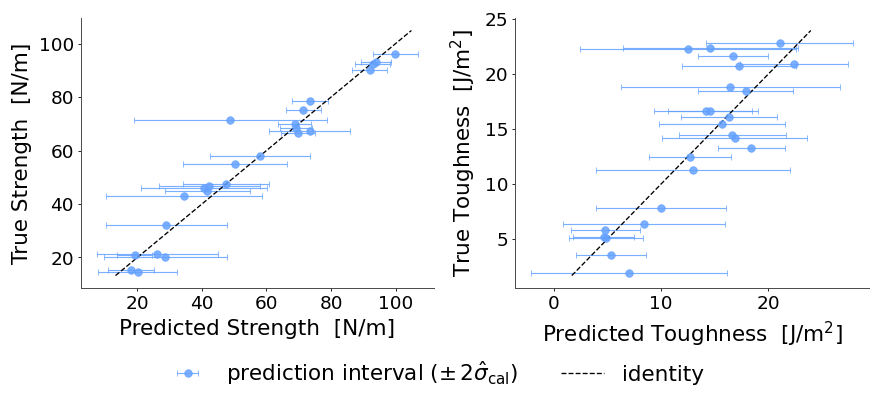

,output,n_test,R2,RMSE,coverage_kappa1,nominal_kappa1,coverage_kappa2,nominal_kappa2
0,Strength,24,0.941,6.152,0.792,0.683,1.000,0.954
1,Toughness,24,0.711,3.499,0.625,0.683,0.917,0.954


In [8]:
te = designs[designs.test]
rows = []
for o in OUTPUTS:
    y, m_, s = te[f"true_{o}"].to_numpy(), te[f"mu_{o}"].to_numpy(), te[f"sigma_cal_{o}"].to_numpy()
    rec = {"output": o, "n_test": len(te), "R2": mu.r2(y, m_), "RMSE": mu.rmse(y, m_)}
    for k in (1.0, 2.0):
        rec[f"coverage_kappa{k:g}"] = float((np.abs(y - m_) <= k * s).mean()); rec[f"nominal_kappa{k:g}"] = 2 * stats.norm.cdf(k) - 1
    rows.append(rec)
test_metrics = pd.DataFrame(rows)
if RETRAIN:
    mu.save_results(test_metrics, "property_test_metrics.csv")

with mpl.rc_context({"font.size": 12, "axes.labelsize": 12.9, "xtick.labelsize": 11.1, "ytick.labelsize": 11.1, "legend.fontsize": 12.9}):
    fig, axes = plt.subplots(1, 2, figsize=(7.38, 3.51))
    fig.subplots_adjust(left=0.10, right=0.99, bottom=0.28, top=0.92, wspace=0.23)
    for ax, o in zip(axes, OUTPUTS):
        y, m_, s = te[f"true_{o}"].to_numpy(), te[f"mu_{o}"].to_numpy(), te[f"sigma_cal_{o}"].to_numpy()
        h_pred = ax.errorbar(m_, y, xerr=2 * s, fmt="o", ms=4.5, markeredgewidth=0.5, elinewidth=0.7, capsize=2, capthick=0.5, color=mu.BLUE, ecolor=mu.BLUE, alpha=0.85)
        lim = [min(y.min(), m_.min()) * 0.9, max(y.max(), m_.max()) * 1.05]
        h_id, = ax.plot(lim, lim, "k--", lw=0.8)
        ax.tick_params(direction="out", length=2, width=0.5, pad=2)
        for spine in ax.spines.values():
            spine.set_linewidth(0.6); spine.set_color("0.3")
        ax.set_xlabel(f"Predicted {o}  [{UNITS[o]}]"); ax.set_ylabel(f"True {o}  [{UNITS[o]}]")
    fig.legend([h_pred, h_id], [r"prediction interval ($\pm\,2\hat\sigma_{\mathrm{cal}}$)", "identity"], loc="lower center", ncol=2,
               bbox_to_anchor=(0.5, 0.0), frameon=False, handlelength=2.0, columnspacing=2.0)
    plt.show()
test_metrics.round(3)

## 6. Learning curve

To quantify how the prediction accuracy depends on the size of the training set, a single network (fixed architecture) is retrained on random subsets of the 94 training designs — 20 to 94 designs, ten draws per size — and evaluated on the fixed 24 testing designs (Supplementary Fig. 18).

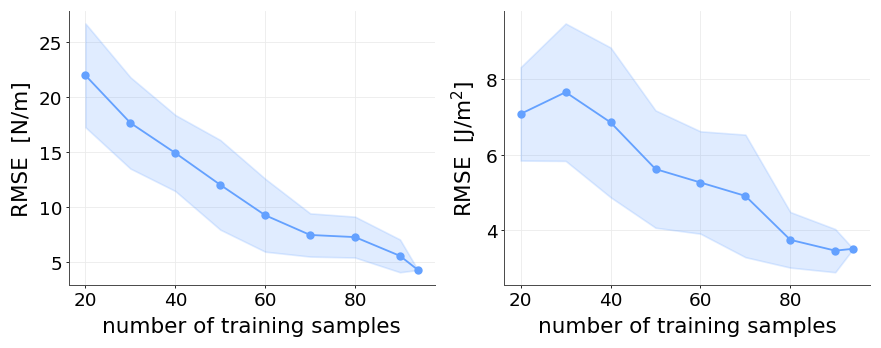

RMSE_Strength       RMSE_Toughness      
            mean   std           mean   std
n                                          
20         21.95  4.70           7.09  1.24
30         17.64  4.14           7.66  1.82
40         14.91  3.45           6.86  1.98
50         12.03  4.06           5.63  1.55
60          9.27  3.31           5.27  1.36
70          7.48  1.96           4.92  1.62
80          7.29  1.85           3.75  0.74
90          5.59  1.48           3.47  0.57
94          4.31  0.00           3.51  0.00

In [34]:
N_GRID = [20, 30, 40, 50, 60, 70, 80, 90, 94]
N_DRAWS = 10


def lc_job(n, rep):
    tr = np.sort(np.random.default_rng(10000 * n + rep).choice(IDX_TRAINVAL, size=n, replace=False))
    xs, ys = mu.Standardiser().fit(X_all[tr]), mu.Standardiser().fit(Y_all[tr])
    net = fit_single_nn(xs.transform(X_all[tr]), ys.transform(Y_all[tr]), MLP_KW["hidden_sizes"], MLP_KW["activation"])
    pred = ys.inverse(mu.predict_mlp(net, xs.transform(X_all[IDX_TEST])))
    rec = {"n": n, "draw": rep}
    for j, o in enumerate(OUTPUTS):
        rec[f"R2_{o}"] = mu.r2(Y_all[IDX_TEST, j], pred[:, j]); rec[f"RMSE_{o}"] = mu.rmse(Y_all[IDX_TEST, j], pred[:, j])
    return rec


if RETRAIN:
    lc = pd.DataFrame(Parallel(n_jobs=N_JOBS, verbose=1)(delayed(lc_job)(n, r) for n in N_GRID for r in range(N_DRAWS)))
    mu.save_results(lc, "learning_curve_per_draw.csv")
else:
    lc = mu.load_results("learning_curve_per_draw.csv")

with mpl.rc_context({"font.size": 12, "axes.labelsize": 12.9, "xtick.labelsize": 11.1, "ytick.labelsize": 11.1}):
    fig, axes = plt.subplots(1, 2, figsize=(7.5, 3))
    fig.subplots_adjust(left=0.10, right=0.99, bottom=0.15, top=0.91, wspace=0.19)
    for ax, o in zip(axes, OUTPUTS):
        g = lc.groupby("n")[f"RMSE_{o}"]; m_, s = g.mean(), g.std(ddof=1)
        ax.plot(m_.index, m_.values, "-o", ms=4, c=mu.BLUE, lw=1.1, zorder=3)
        ax.fill_between(m_.index, np.clip(m_ - s, 0, None).values, (m_ + s).values, color=mu.BLUE, alpha=0.2, zorder=2)
        ax.set_xlabel("number of training samples"); ax.set_ylabel(f"RMSE  [{UNITS[o]}]")
        ax.set_xticks([20, 40, 60, 80])
        ax.grid(color="0.92", linewidth=0.5, zorder=0)
        ax.tick_params(direction="out", length=2, width=0.5, pad=2)
        for spine in ax.spines.values():
            spine.set_linewidth(0.6); spine.set_color("0.3")
    plt.show()
lc.groupby("n")[[f"RMSE_{o}" for o in OUTPUTS]].agg(["mean", "std"]).round(2)

## 7. Using the deployed ensemble

`NNEnsemble.load` restores the 20 members, the standardiser and the calibration factors; `predict` returns the ensemble mean, the raw spread and the calibrated uncertainty in physical units.

In [10]:
ens = mu.NNEnsemble.load(f"{mu.MODELS_DIR}/nn_ensemble")
x_new = np.array([[1.05, 2.0], [1.5, 1.6], [1.9, 2.4]])
m_, s_uc, s_cal = ens.predict(x_new)
pd.DataFrame({"L0Bar": x_new[:, 0], "L0Y": x_new[:, 1],
              **{f"mu_{o}": m_[:, j] for j, o in enumerate(OUTPUTS)},
              **{f"sigma_cal_{o}": s_cal[:, j] for j, o in enumerate(OUTPUTS)}}).round(2)

,L0Bar,L0Y,mu_Strength,mu_Toughness,sigma_cal_Strength,sigma_cal_Toughness
0,1.05,2.0,85.74,12.82,12.59,3.70
1,1.50,1.6,15.79,17.36,5.72,2.51
2,1.90,2.4,20.37,18.94,3.18,2.43


## Outputs

* `results/nn_architecture_grid.csv` — validation error of every architecture (Supplementary Table 4).
* `results/property_benchmark_predictions.csv`, `results/property_benchmark_per_split.csv`, `results/property_benchmark_summary.csv` — benchmark over the 20 random splits (Supplementary Table 5).
* `results/calibration_oof_pairs.csv`, `results/calibration_factors.csv`, `results/calibration_diagnostics.csv` — calibration (Supplementary Table 6).
* `results/property_ensemble_designs.csv`, `results/property_test_metrics.csv` — deployed ensemble at the 118 designs and its test-set accuracy.
* `results/learning_curve_per_draw.csv` — learning curve.
* `models/nn_ensemble/` — the deployed ensemble (20 members, standardiser, calibration factors), loaded by `pareto_optimization.ipynb`.